Топ-5 жанров: ['Romance', 'Nonfiction', 'History', 'Sequential Art', 'Fantasy']

Размер после фильтрации: 3000
primary_genre
Fantasy           600
History           600
Nonfiction        600
Romance           600
Sequential Art    600
Name: count, dtype: int64

Пример строки:
Жанр: Fantasy
Аннотация: A spin-off of the "Partnership in Blood" series. , Thanks to the efforts of Raymond Payet and l'ANS, vampires now have the same legal rights as mortals, and research at l'Institut Marcel Chavinier is  ...

Train: 2400, Val: 300, Test: 300
Сохранено: train.csv, val.csv, test.csv

=== Baseline (TF-IDF + LogReg) ===
Accuracy: 0.733
                precision    recall  f1-score   support

       Fantasy       0.68      0.65      0.67        60
       History       0.72      0.83      0.78        60
    Nonfiction       0.77      0.72      0.74        60
       Romance       0.75      0.78      0.76        60
Sequential Art       0.75      0.68      0.71        60

      accuracy               

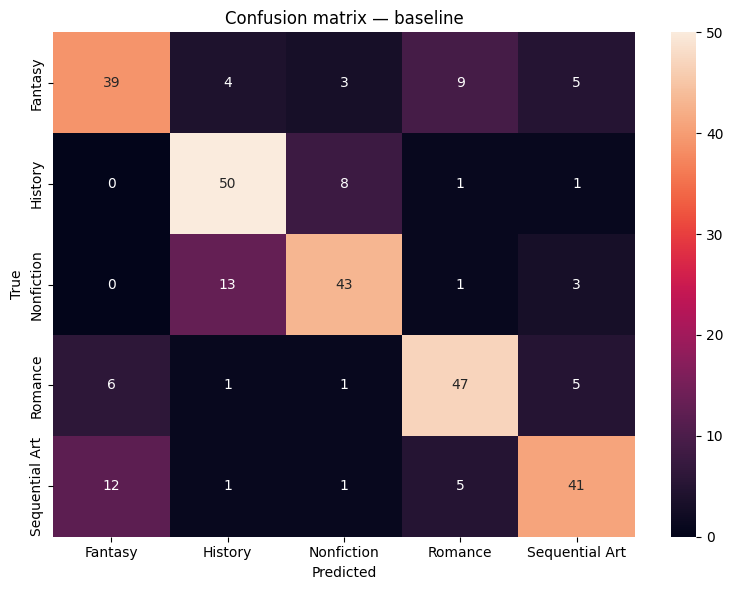

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("books.csv")

# Основной жанр — первый тег
df["primary_genre"] = (
    df["genre"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

# Длина аннотации
df["desc_len"] = df["desc"].fillna("").astype(str).str.len()

# Только нормальные аннотации и непустой жанр
df = df[(df["desc_len"] >= 80) & (df["primary_genre"] != "")].copy()

# Топ-5 жанров (без пустых)
TOP_GENRES = df["primary_genre"].value_counts().head(5).index.tolist()
print("Топ-5 жанров:", TOP_GENRES)

df = df[df["primary_genre"].isin(TOP_GENRES)]

samples = []
for _, group in df.groupby("primary_genre"):
    samples.append(group.sample(min(len(group), 600), random_state=42))
df = pd.concat(samples, ignore_index=True)

print("\nРазмер после фильтрации:", len(df))
print(df["primary_genre"].value_counts())
print("\nПример строки:")
row = df.iloc[0]
print("Жанр:", row["primary_genre"])
print("Аннотация:", row["desc"][:200], "...")

X = df["desc"]
y = df["primary_genre"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Сохраняем те же splitы для DistilBERT
pd.DataFrame({"text": X_train, "label": y_train}).to_csv("train.csv", index=False)
pd.DataFrame({"text": X_val, "label": y_val}).to_csv("val.csv", index=False)
pd.DataFrame({"text": X_test, "label": y_test}).to_csv("test.csv", index=False)
print("Сохранено: train.csv, val.csv, test.csv")

# Baseline: TF-IDF + Logistic Regression
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("\n=== Baseline (TF-IDF + LogReg) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

# Матрица
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — baseline")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150)
print("Сохранено: confusion_matrix_baseline.png")
